In [1]:
import torch
import torch.nn as nn

from torch_geometric.nn import knn_graph
from torch_geometric.loader import DataLoader

import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import gc

In [2]:

from segnn.segnn import SEGNN
from e3nn.o3 import Irreps, spherical_harmonics
from segnn.balanced_irreps import BalancedIrreps, WeightBalancedIrreps

# use it for input features similar to hemodynamics paper
from Utility_functions import print_3D_graph, Graph_dataset_with_equiv_features

In [3]:
dev = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# dev = "cpu"
print(dev)

cpu


# Model

In [4]:
gc.collect()
torch.cuda.empty_cache()

# change the path accordingly
path = '../.data/Dataset_1000sims_5G2N/checkpoints/best_model.pt'

checkpoint = torch.load(path)

input_irreps = checkpoint['input_irreps']
hidden_irreps = checkpoint['hidden_irreps']
output_irreps = checkpoint['output_irreps']
edge_attr_irreps = checkpoint['edge_attr_irreps']
node_attr_irreps = checkpoint['node_attr_irreps']
task = checkpoint['task']
norm=checkpoint['norm']
num_layers=checkpoint['num_layers']
additional_message_irreps=checkpoint['additional_message_irreps']

model = SEGNN(input_irreps=input_irreps,
              hidden_irreps=hidden_irreps,
              output_irreps=output_irreps,
              edge_attr_irreps=edge_attr_irreps,
              node_attr_irreps=node_attr_irreps,
              task=task,
              norm=norm,
              num_layers=num_layers,
              additional_message_irreps=additional_message_irreps
              )

model = checkpoint['model']

loss_func = nn.MSELoss()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(count_parameters(model))

model.to(dev)
model.eval()

16779


SEGNN(
  (embedding_layer): O3TensorProduct(
    (tp): FullyConnectedTensorProduct(2x1o+2x0e x 1x0e+1x1o -> 34x0e+10x1o | 176 paths | 176 weights)
  )
  (layers): ModuleList(
    (0): SEGNNLayer()
  )
  (pre_pool1): O3TensorProductSwishGate(
    (tp): FullyConnectedTensorProduct(34x0e+10x1o x 1x0e+1x1o -> 44x0e+10x1o | 2376 paths | 2376 weights)
    (gate): Gate (44x0e+10x1o -> 34x0e+10x1o)
  )
  (pre_pool2): O3TensorProduct(
    (tp): FullyConnectedTensorProduct(34x0e+10x1o x 1x0e+1x1o -> 1x0e+1x1o | 88 paths | 88 weights)
  )
)

In [6]:
# change the root path accordingly
dataset = Graph_dataset_with_equiv_features(root = '../.data/Dataset_1000sims_5G2N')

100%|██████████| 1000/1000 [00:00<00:00, 852674.12it/s]


In [7]:
# Dataset split 80-10-10
num_workers = 8

dataset_length = len(dataset)
train_length, test_length = train_test_split(range(dataset_length), test_size = 0.2, shuffle = False)
val_length, test_length = train_test_split(range(len(test_length)), test_size = 0.5, shuffle = False)
test_dataset = dataset[test_length]

loader = DataLoader(test_dataset, batch_size = 1, shuffle = False, num_workers = num_workers)

# Test loss

In [8]:
outputs = []
loss = []

# mask = True
neighbours = 10

fluid_nodes = torch.tensor(2)

# s is the sample graph
for s in tqdm(loader): 


    edge_index = knn_graph(s.pos, neighbours, s.batch)
    s.edge_index = edge_index

    edge_relativePos = (torch.index_select(s.pos, 0, edge_index[1]) - torch.index_select(s.pos, 0, edge_index[0]))
    edge_relativeDist = torch.norm(edge_relativePos, dim = -1, keepdim = True) 
    edge_attr = torch.cat([edge_relativeDist, edge_relativePos], dim = -1) 

    s.edge_attr = edge_attr
    #s.node_attr = s.pos
    
    s = s.to(dev)
    with torch.no_grad():
        
        if s.mask is not None:
            mask = s.mask
        else:
            mask = torch.ones(s.x.shape[0], dtype=torch.bool)
            
        out = model(s)
        loss_val = loss_func(out[mask], s.y[mask])
        
    
    outputs.append(out)
    loss.append(loss_val.item())

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\crist\anaconda3\envs\segnn\lib\site-packages\torch_geometric\deprecation.py:13: UserWarning: 'contains_isolated_nodes' is deprecated, use 'has_isolated_nodes' instead
  warnings.warn(out)
100%|██████████| 100/100 [00:13<00:00,  7.62it/s]


In [9]:
# save = True
save = True

if save:
    nploss = np.save('loss.npy', loss)

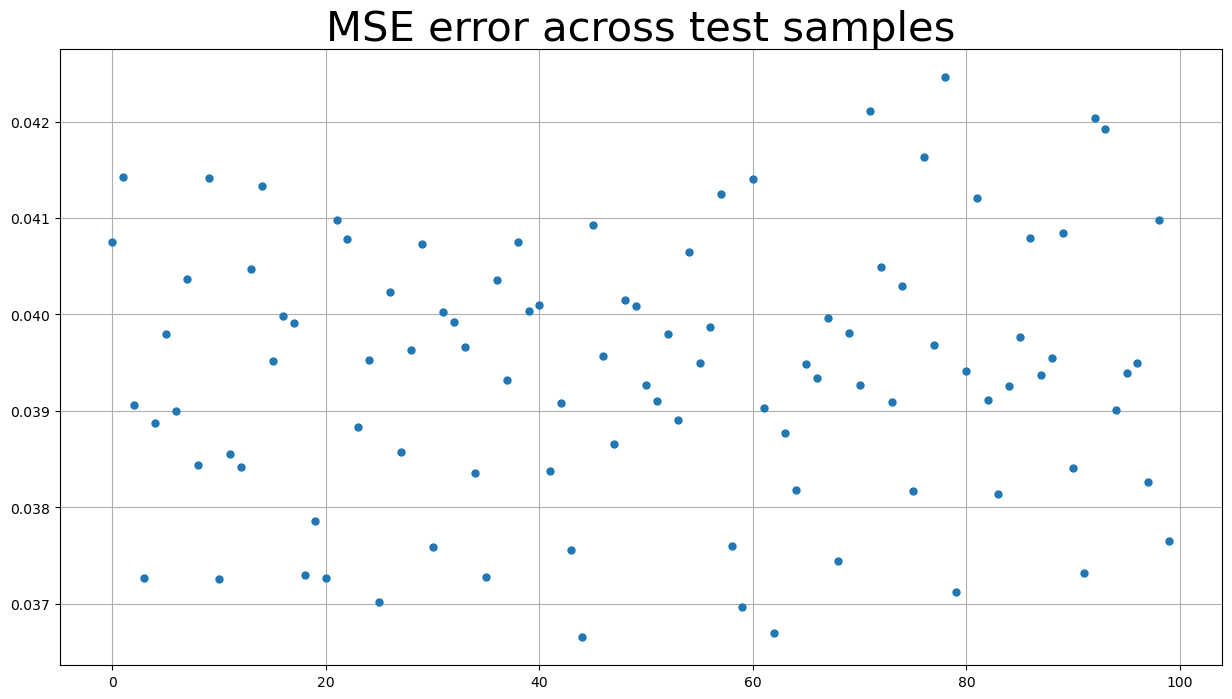

In [10]:
plt.figure(figsize=(15,8))
plt.plot(range(len(loss)), loss, marker = 'o', markersize=5,
         linewidth=0)
plt.title('MSE error across test samples', size = 30)
plt.grid()
plt.show()

# Test set plots

Number of test samples: 100


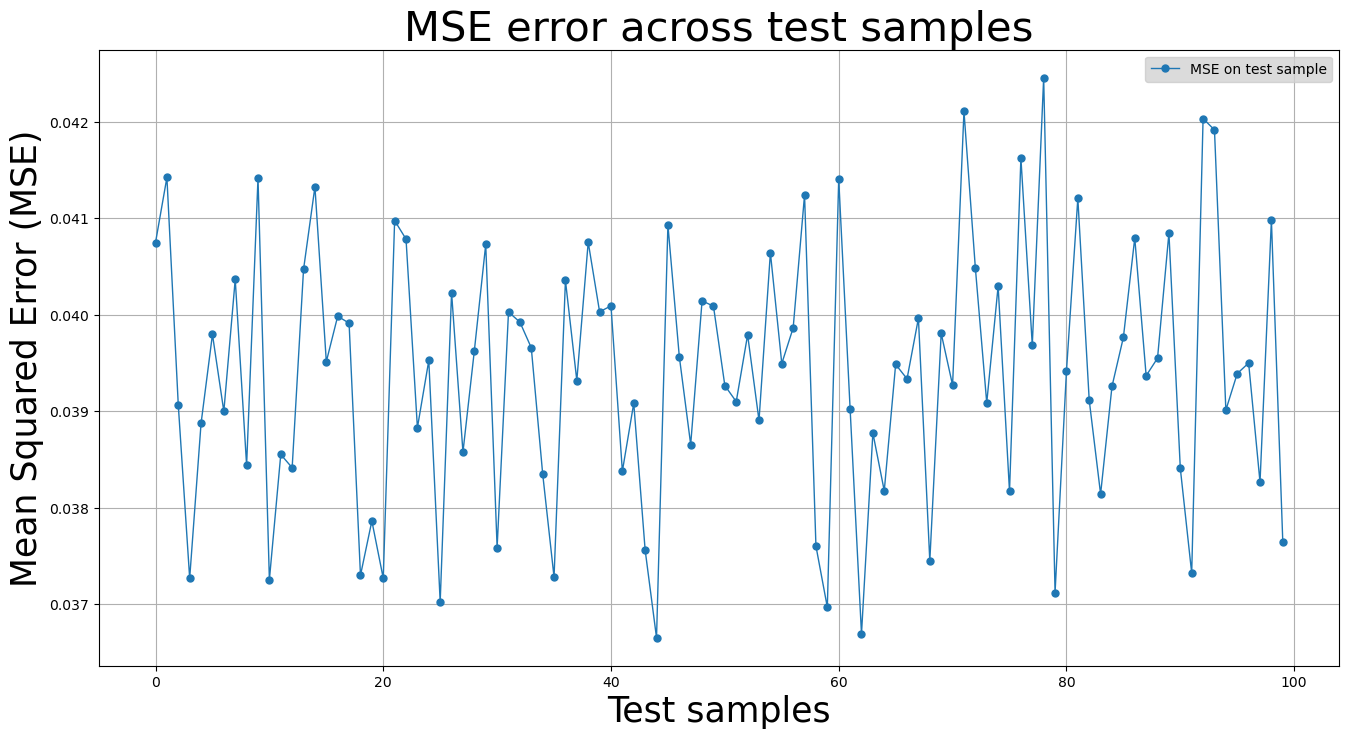

In [11]:
loadloss = np.load('loss.npy')

plt.figure(figsize=(16,8))

plt.plot(range(len(loadloss)), loadloss, marker='o', markersize=5,
         linewidth=1, label='MSE on test sample')

plt.xlabel('Test samples', size=25)
plt.ylabel('Mean Squared Error (MSE)', size=25)
plt.title('MSE error across test samples', size=30)
plt.grid()
legend = plt.legend()
legend.get_frame().set_facecolor('lightgray')

print("Number of test samples:", len(loadloss))

plt.show()

# Single test plot

In [12]:

# idx ofgraph (steady state) to plot
idx = 0
test_graph = test_dataset[idx]


with torch.no_grad():

    edge_index = knn_graph(test_graph.pos, neighbours, test_graph.batch)
    test_graph.edge_index = edge_index
    
    edge_relativePos = (torch.index_select(test_graph.pos, 0, edge_index[1]) - torch.index_select(test_graph.pos, 0, edge_index[0]))
    edge_relativeDist = torch.norm(edge_relativePos, dim = -1, keepdim = True) 
    edge_attr = torch.cat([edge_relativeDist, edge_relativePos], dim = -1) 
    
    test_graph.edge_attr = edge_attr
    #test_graph.node_attr = test_graph.pos


    pred = model(test_graph.to(dev))

: 

In [ ]:
# remember that to plot the graphs ignoring the ground truth velocities and pressures, you have
# to plot pred[sample.mask], and not simply the "pred" tensor (which contains predictions on all nodes,
# included the ones that were masked out during training because true values were used in the input, and 
# that were not taken care of by backpropagation)

# Ground truth

In [ ]:
# edges = knn_graph(test_graph.pos, 10)
magvel = torch.norm(test_graph.cpu().y[mask,1:4], dim=-1)
press = torch.norm(test_graph.cpu().y[mask,[0]], dim=-1)

colors = magvel
print_3D_graph(test_graph.pos.cpu(), edges = None, color = colors)

# Prediction

In [ ]:
magvel2 = torch.norm(pred[mask,1:4], dim=-1)
press2 = torch.norm(pred[mask,[0]], dim=-1)

colors2 = press2
# colors2 = press2.cpu()-press
# colors2 = np.abs(press2.cpu()-press)/press
# colors2 = np.log10(np.abs(press2.cpu()-press)/press)

colors2 = magvel2
# colors2 = np.abs(magvel2.cpu()-magvel)
# colors2 = np.abs(magvel2.cpu()-magvel)/magvel
# colors2 = np.log10(np.abs((magvel2.cpu() - magvel)/magvel))
# colors2 = press2.cpu() - press

# colors2 = pred[...,1]
# colors2 = (colors2.cpu()-colors)
# colors2 = (np.abs((colors2.cpu()-colors)/colors))
# colors2 = np.log10(np.abs((colors2.cpu()-colors)/colors))

print_3D_graph(test_graph.pos.cpu(), edges = None, color = colors2.cpu())